In [3]:
from google.colab import files
uploaded = files.upload()


Saving zoo.csv to zoo.csv


In [4]:
from google.colab import files
uploaded = files.upload()


Saving class.csv to class.csv


In [5]:
from google.colab import files
uploaded = files.upload()


Saving auxiliary_metadata.json to auxiliary_metadata.json


--- Starting Data Pipeline in Colab ---
Data loading, cleaning, and feature engineering complete.

--- Task 2: Final Processed Data Validation ---
1. Final Dataset Shape: (100, 25)
2. Missing Values (isnull().sum()): 0
3. Duplicate Rows (sum()): 0

4. Final Data Head (First 3 Rows):
| animal_name   | Class_Type   | diet        | habitat_type   | habitat_risk_score   | trophic_level   |
|:--------------|:-------------|:------------|:---------------|:---------------------|:----------------|
| aardvark      | Mammal       | insectivore | savanna        | 1                    | 1               |
| antelope      | Mammal       | herbivore   | grasslands     | 1                    | 1               |
| bass          | Fish         | carnivore   | freshwater     | 2                    | 3               |

--- Generating EDA Plots (Displayed Inline) ---


/tmp/ipython-input-1952187227.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, orient='h', palette='viridis')


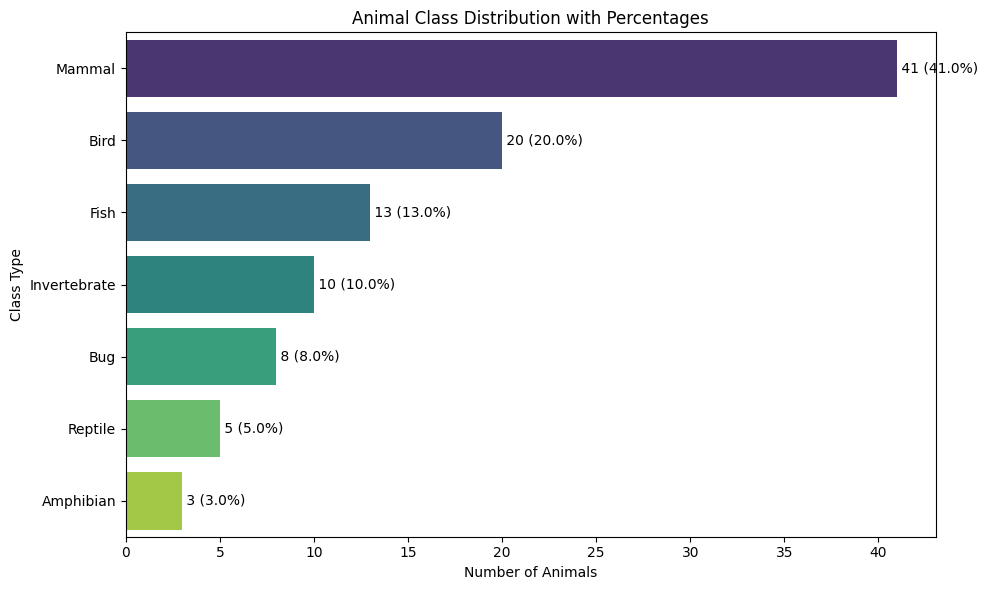

/tmp/ipython-input-1952187227.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class_Type', y=feature, data=df, palette='Set2')


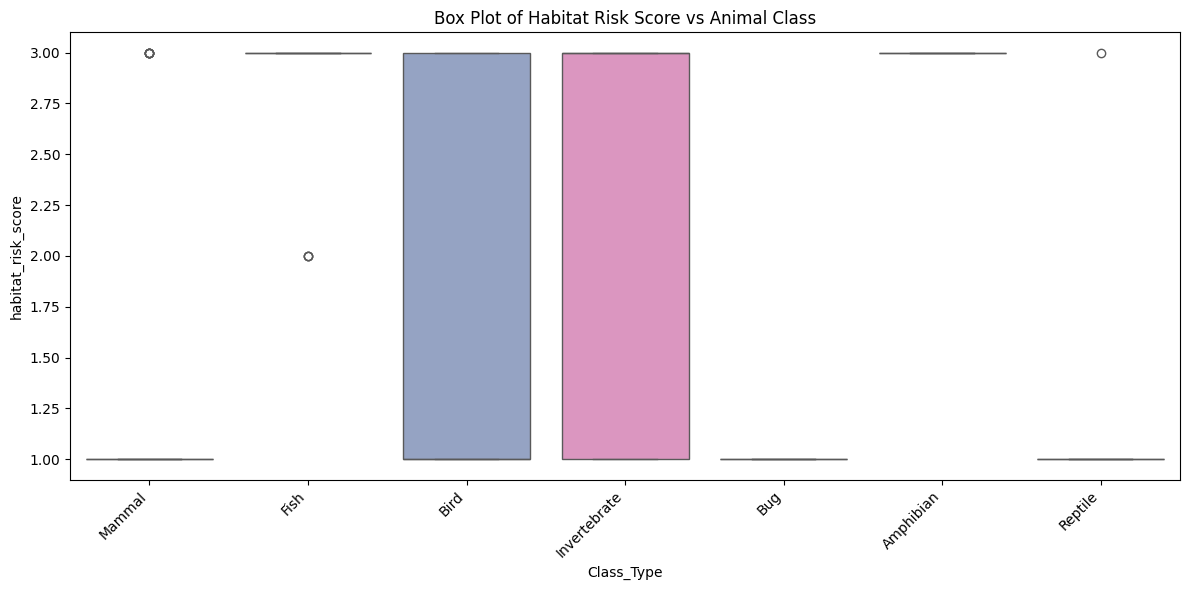

/tmp/ipython-input-1952187227.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class_Type', y=feature, data=df, palette='Set2')


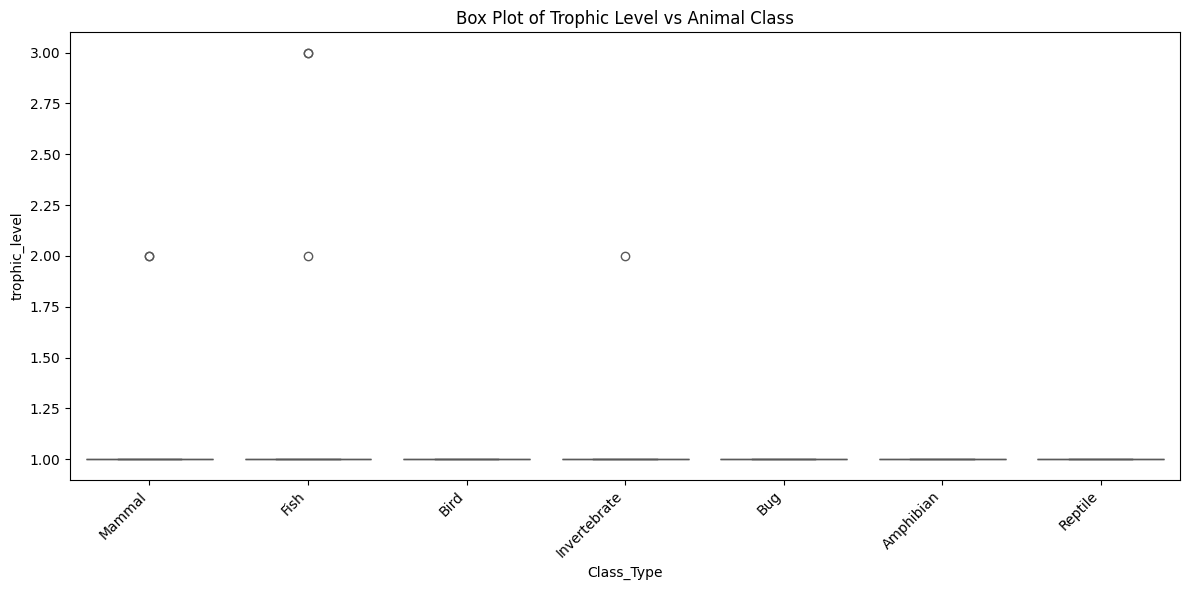

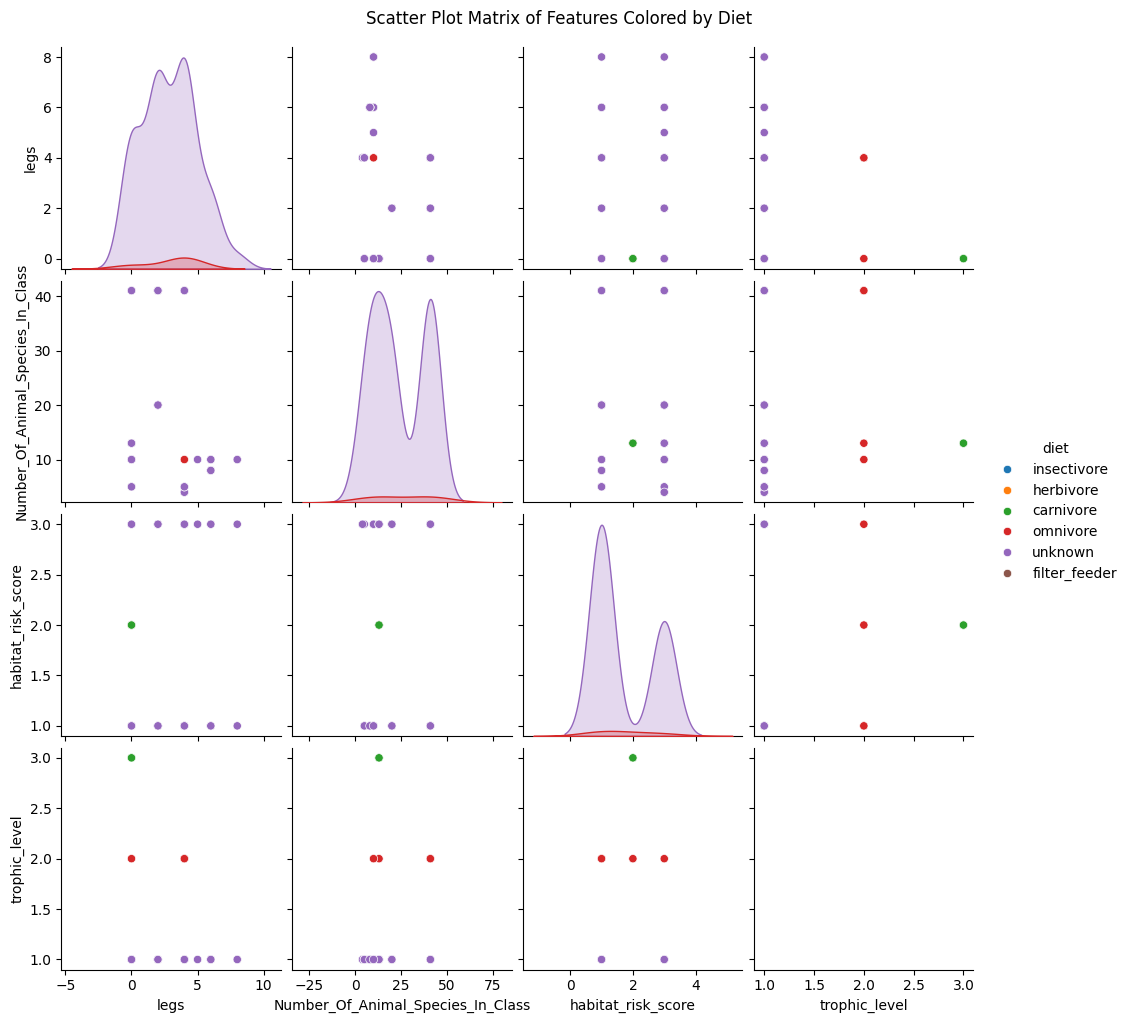

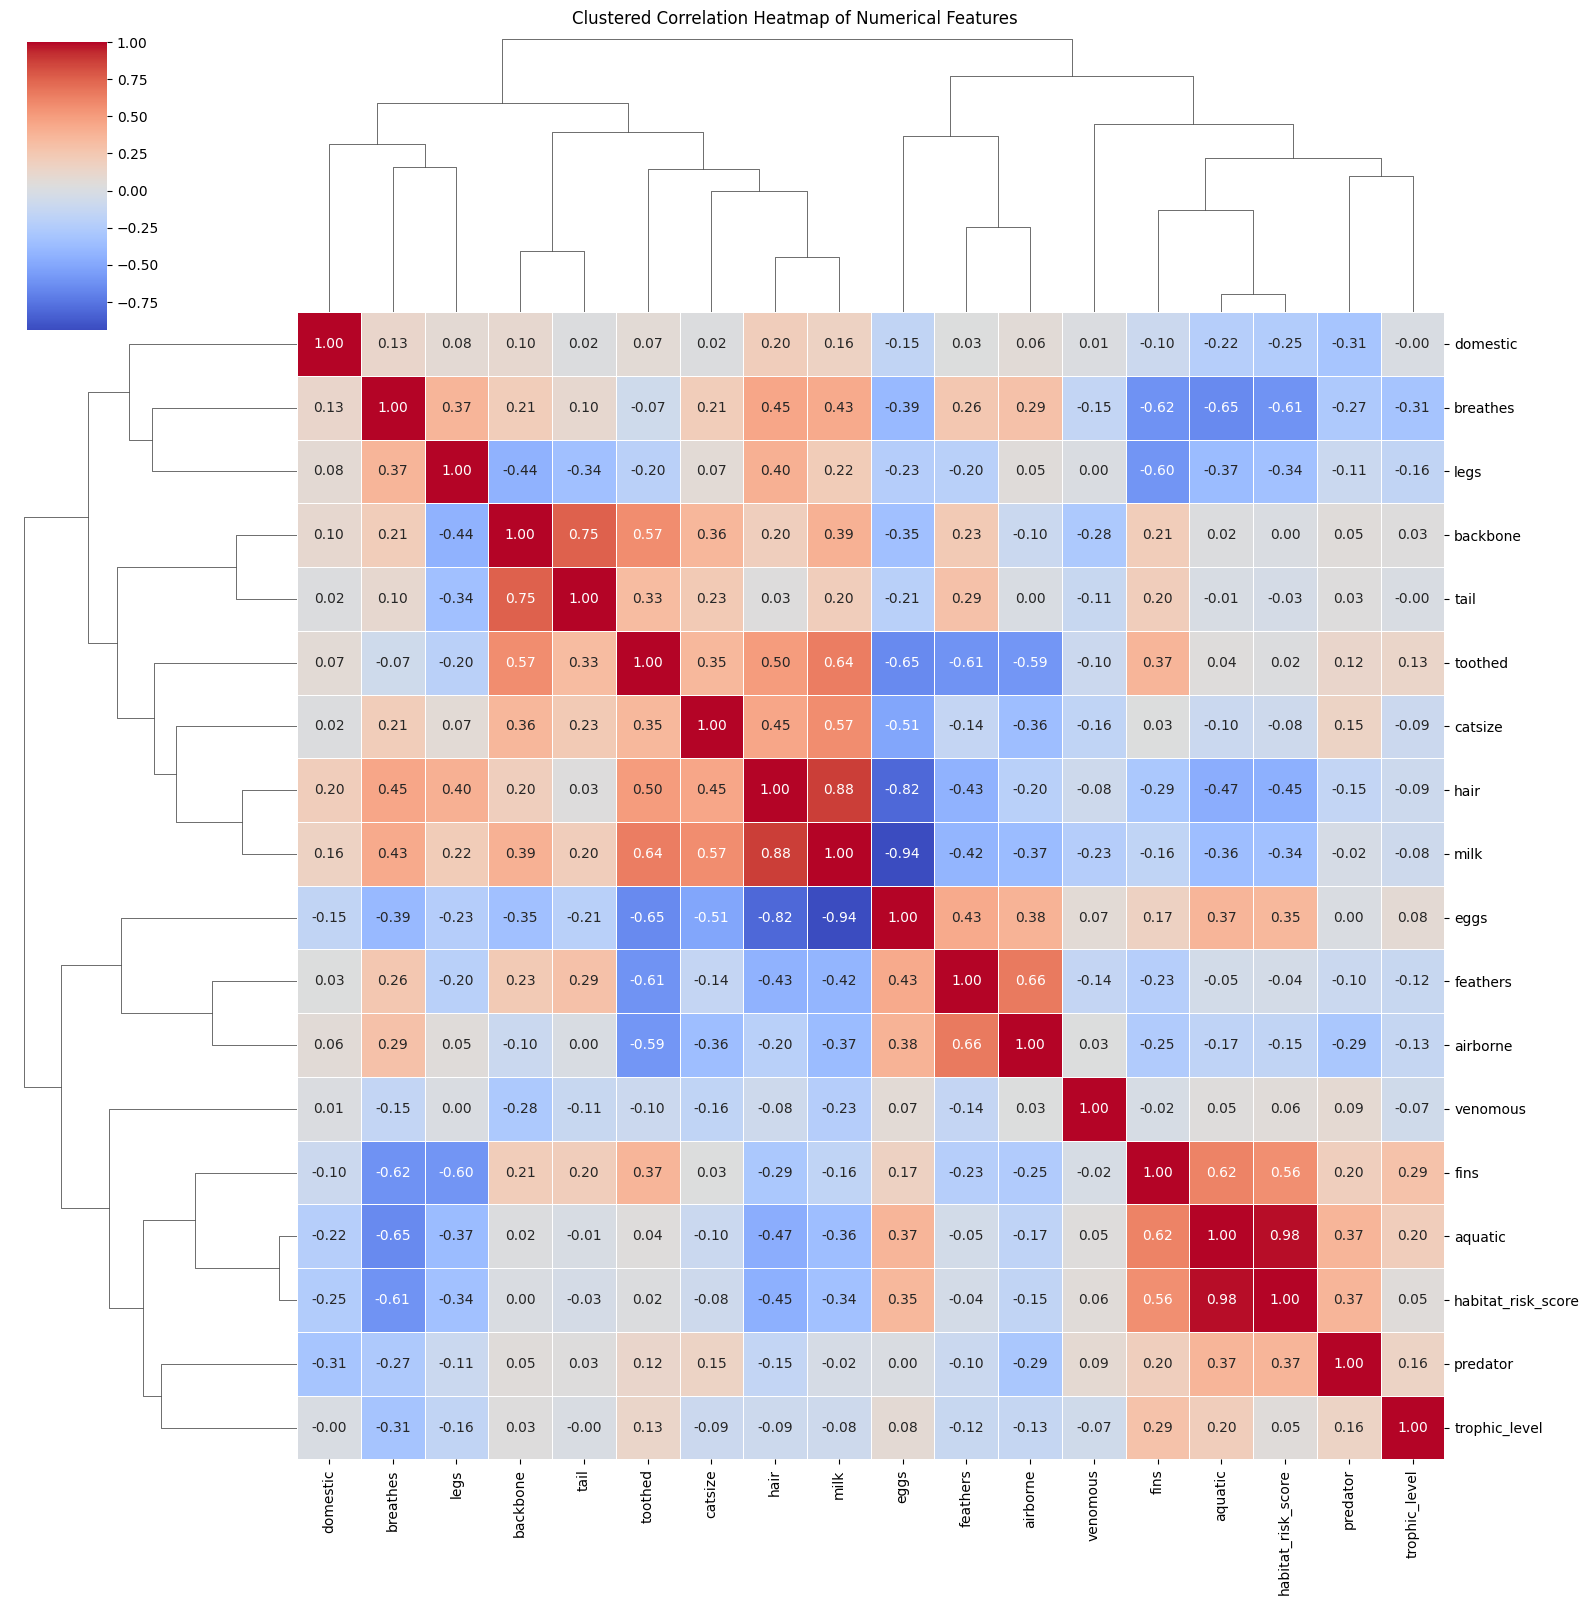


--- Statistical Analysis Results (EDA) ---
1. Class Imbalance Ratio: 13.67

2. Highly Correlated Pairs (|Correlation| > 0.8):
- eggs and hair: -0.82
- milk and hair: 0.88
- milk and eggs: -0.94
- habitat_risk_score and aquatic: 0.98

--- Model Training and Evaluation ---

Random Forest Testing Accuracy: 1.0000

Classification Report (RF):
|              | precision   | recall   | f1-score   | support   |
|:-------------|:------------|:---------|:-----------|:----------|
| Amphibian    | 1           | 1        | 1          | 1         |
| Bird         | 1           | 1        | 1          | 6         |
| Bug          | 1           | 1        | 1          | 2         |
| Fish         | 1           | 1        | 1          | 4         |
| Invertebrate | 1           | 1        | 1          | 3         |
| Mammal       | 1           | 1        | 1          | 12        |
| Reptile      | 1           | 1        | 1          | 2         |
| accuracy     | 1           | 1        | 1          | 

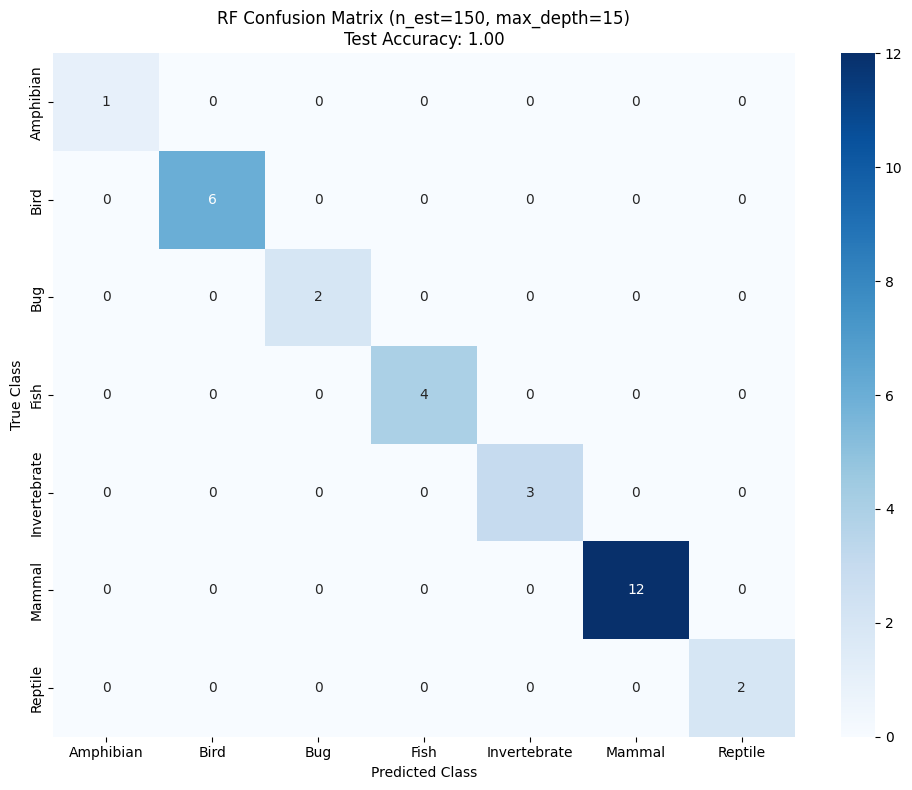

/tmp/ipython-input-1952187227.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_features, palette=colors)


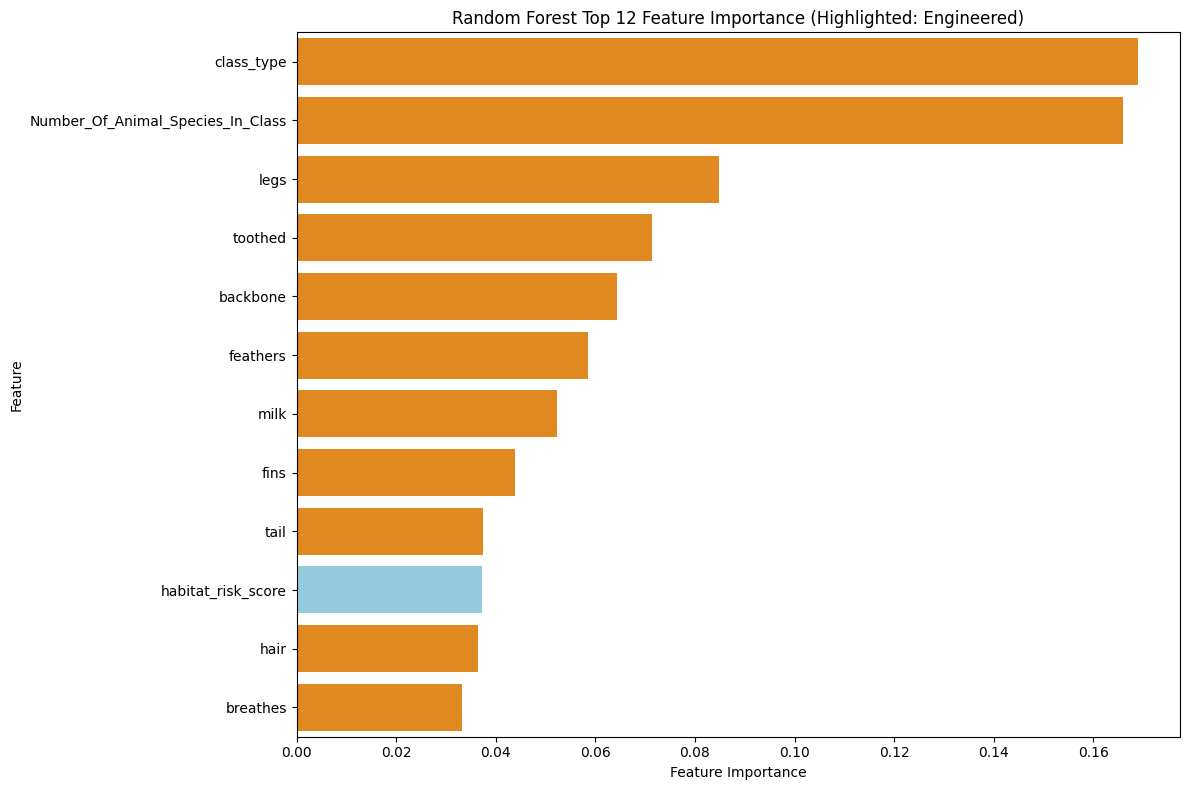


K-Nearest Neighbors (k=5) Test Accuracy: 0.9667

Pipeline finished. Final processed data saved to 'final_model_ready_zoo_data.csv'


In [20]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =============================================================================
# TASK 1 & 2: DATA INTEGRATION, CLEANING, AND FEATURE ENGINEERING
# =============================================================================

def Beta_load_and_integrate():
    """Loads, integrates, and performs initial normalization."""
    # Load files
    df_zoo = pd.read_csv('zoo.csv')
    with open('auxiliary_metadata.json', 'r') as f:
        data_auxiliary = json.load(f)
    df_auxiliary = pd.DataFrame(data_auxiliary)
    df_class = pd.read_csv('class.csv')

    # Merge zoo.csv and class.csv
    primary_df = pd.merge(df_zoo, df_class[['Class_Number', 'Class_Type', 'Number_Of_Animal_Species_In_Class']],
                          left_on='class_type', right_on='Class_Number', how='left').drop(columns=['Class_Number'])
    # Merge with auxiliary data
    integrated_df = pd.merge(primary_df, df_auxiliary, on='animal_name', how='left')

    # Normalization (Case-Insensitive Duplicate Removal)
    integrated_df['animal_name_lower'] = integrated_df['animal_name'].str.lower()
    df_normalized = integrated_df.drop_duplicates(subset=['animal_name_lower'], keep='first').drop(columns=['animal_name_lower'])
    return df_normalized

def Beta_data_cleaning(df):
    """Standardizes column names and values from auxiliary data inconsistencies."""
    df['conservation_status'] = df['conservation_status'].combine_first(df['conservation']).combine_first(df['status'])
    df = df.drop(columns=['conservation', 'status'], errors='ignore')
    df['habitat_type'] = df['habitat'].combine_first(df['habitats'])
    df = df.drop(columns=['habitat', 'habitats'], errors='ignore')
    df['habitat_type'] = df['habitat_type'].str.lower().str.replace('fresh water', 'freshwater', case=False, regex=False)
    df['diet'] = df['diet'].combine_first(df['diet_type'])
    df = df.drop(columns=['diet_type'], errors='ignore')

    diet_typo_map = {'omnivor': 'omnivore'}
    df['diet'] = df['diet'].str.lower().replace(diet_typo_map)
    return df

def Beta_final_processing(df):
    """Handles missing values and performs feature engineering."""
    # Impute Missing Values
    numerical_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(include='object').columns

    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())
    for col in categorical_cols:
        df[col] = df[col].fillna("unknown")

    # Feature Engineering: habitat_risk_score
    def calculate_habitat_risk(row):
        is_freshwater = 'freshwater' in row['habitat_type']
        if row['aquatic'] == 1 and not is_freshwater:
            return 3
        elif is_freshwater:
            return 2
        else:
            return 1
    df['habitat_risk_score'] = df.apply(calculate_habitat_risk, axis=1)

    # Feature Engineering: trophic_level
    def calculate_trophic_level(diet):
        if 'carnivore' in diet:
            return 3
        elif 'omnivore' in diet:
            return 2
        else:
            return 1
    df['trophic_level'] = df['diet'].apply(calculate_trophic_level)

    return df

# =============================================================================
# TASK 3: EXPLORATORY DATA ANALYSIS (EDA) AND PLOTTING
# =============================================================================

def beta_eda_and_cleaning(df):
    """
    Performs EDA including visualizations (plots saved and printed) and
    statistical analysis metrics.
    """

    # 1. VISUALIZATIONS

    print("\n--- Generating EDA Plots (Displayed Inline) ---")

    # a) Horizontal bar chart: Class distribution
    class_counts = df['Class_Type'].value_counts()
    class_percentages = class_counts / len(df) * 100

    plt.figure(figsize=(10, 6))
    sns.barplot(x=class_counts.values, y=class_counts.index, orient='h', palette='viridis')
    plt.title('Animal Class Distribution with Percentages')
    plt.xlabel('Number of Animals')
    plt.ylabel('Class Type')
    for index, value in enumerate(class_counts.values):
        percentage = class_percentages.iloc[index]
        plt.text(value, index, f' {value} ({percentage:.1f}%)', va='center')
    plt.tight_layout()
    plt.savefig('class_distribution_bar_chart.png')
    plt.show()
    plt.close()

    # b) Box plots for engineered features vs classes
    engineered_features = ['habitat_risk_score', 'trophic_level']
    for feature in engineered_features:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x='Class_Type', y=feature, data=df, palette='Set2')
        plt.title(f'Box Plot of {feature.replace("_", " ").title()} vs Animal Class')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f'boxplot_{feature}_vs_class.png')
        plt.show()
        plt.close()

    # c) Scatter plot matrix
    scatter_features = ['legs', 'Number_Of_Animal_Species_In_Class', 'habitat_risk_score', 'trophic_level']
    g = sns.pairplot(df, vars=scatter_features, hue='diet', palette='tab10', diag_kind='kde')
    g.fig.suptitle('Scatter Plot Matrix of Features Colored by Diet', y=1.02)
    g.savefig('scatter_plot_matrix_diet.png')
    plt.show()
    plt.close()

    # d) Correlation heatmap with clustering
    numerical_df_corr = df.select_dtypes(include=np.number).drop(columns=['class_type', 'Number_Of_Animal_Species_In_Class'], errors='ignore')
    corr_matrix = numerical_df_corr.corr()
    g = sns.clustermap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, figsize=(16, 16))
    g.fig.suptitle('Clustered Correlation Heatmap of Numerical Features', y=1.00)
    g.savefig('correlation_clustermap.png')
    plt.show()
    plt.close()

    # 2. STATISTICAL ANALYSIS (Prints to console)
    print("\n--- Statistical Analysis Results (EDA) ---")

    class_counts = df['Class_Type'].value_counts()
    class_imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"1. Class Imbalance Ratio: {class_imbalance_ratio:.2f}")

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    highly_correlated_pairs = [(col, row, upper.loc[row, col])
                               for row in upper.index
                               for col in upper.columns
                               if abs(upper.loc[row, col]) > 0.8]

    print("\n2. Highly Correlated Pairs (|Correlation| > 0.8):")
    if highly_correlated_pairs:
        for pair in highly_correlated_pairs:
            print(f"- {pair[0]} and {pair[1]}: {pair[2]:.2f}")

    return df

# =============================================================================
# TASK 4: MODEL TRAINING, EVALUATION, AND PLOTTING
# =============================================================================

def beta_train_and_evaluate(df):
    """
    Trains and evaluates Random Forest and KNN models, and provides
    evaluation plots.
    """

    # 1. Data Preparation
    X = df.drop(columns=['animal_name', 'Class_Type'])
    y = df['Class_Type']

    X = pd.get_dummies(X, columns=['diet', 'habitat_type', 'conservation_status'], drop_first=True)

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_labels = le.classes_

    # 2. Split Data (70% train, 30% test, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    )

    # --- Model 1: Random Forest Classifier (RF) ---
    print("\n--- Model Training and Evaluation ---")

    rf_model = RandomForestClassifier(
        n_estimators=150, max_depth=15, min_samples_split=2, random_state=42, class_weight='balanced'
    )
    rf_model.fit(X_train, y_train)

    y_test_pred_rf = rf_model.predict(X_test)
    test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

    print(f"\nRandom Forest Testing Accuracy: {test_acc_rf:.4f}")

    # 5. Classification Report
    report_rf = classification_report(y_test, y_test_pred_rf, target_names=class_labels, output_dict=True)
    report_df_rf = pd.DataFrame(report_rf).transpose().round(2)
    print("\nClassification Report (RF):")
    print(report_df_rf.to_markdown(numalign="left", stralign="left"))

    # 6. Confusion Matrix Heatmap (rf_confusion_matrix.png)
    print("\n--- Generating Evaluation Plots (Displayed Inline) ---")
    cm_rf = confusion_matrix(y_test, y_test_pred_rf)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'RF Confusion Matrix (n_est=150, max_depth=15)\nTest Accuracy: {test_acc_rf:.2f}')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.tight_layout()
    plt.savefig('rf_confusion_matrix.png')
    plt.show()
    plt.close()

    # 7. Feature Importance Horizontal Bar Chart (rf_feature_importance.png)
    importances = rf_model.feature_importances_
    feature_names = X_train.columns
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    top_n = 12
    top_features = feature_importance_df.head(top_n)

    engineered_features = ['habitat_risk_score', 'trophic_level']
    colors = ['skyblue' if f in engineered_features else 'darkorange' for f in top_features['feature']]

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=top_features, palette=colors)
    plt.title(f'Random Forest Top {top_n} Feature Importance (Highlighted: Engineered)')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig('rf_feature_importance.png')
    plt.show()
    plt.close()

    # --- Model 2: K-Nearest Neighbors (KNN) ---
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    y_test_pred_knn = knn_model.predict(X_test)
    test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

    print(f"\nK-Nearest Neighbors (k=5) Test Accuracy: {test_acc_knn:.4f}")

    return df

# =============================================================================
# EXECUTION CHAIN (Prints all outputs)
# =============================================================================
if __name__ == '__main__':
    print("--- Starting Data Pipeline in Colab ---")

    # Task 1 & 2: Load, Clean, and Engineer
    df_normalized = Beta_load_and_integrate()
    df_cleaned = Beta_data_cleaning(df_normalized)
    df_final = Beta_final_processing(df_cleaned)
    print("Data loading, cleaning, and feature engineering complete.")

    # Data Validation Check
    print("\n--- Task 2: Final Processed Data Validation ---")
    print(f"1. Final Dataset Shape: {df_final.shape}")
    print(f"2. Missing Values (isnull().sum()): {df_final.isnull().sum().sum()}")
    print(f"3. Duplicate Rows (sum()): {df_final.duplicated().sum()}")
    print("\n4. Final Data Head (First 3 Rows):")
    print(df_final[['animal_name', 'Class_Type', 'diet', 'habitat_type', 'habitat_risk_score', 'trophic_level']].head(3).to_markdown(index=False, numalign="left", stralign="left"))


    # Task 3: EDA (Plots and Stats printed)
    df_eda_result = beta_eda_and_cleaning(df_final)

    # Task 4: Model Training and Evaluation (Plots and Metrics printed)
    df_model_ready = beta_train_and_evaluate(df_final)

    # Save final processed data
    df_model_ready.to_csv('final_model_ready_zoo_data.csv', index=False)
    print("\nPipeline finished. Final processed data saved to 'final_model_ready_zoo_data.csv'")